#### 1.Importing Libraries


In [33]:
import pandas as pd
import pandas as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_ind
from decimal import Decimal

#### 2.Load Dataset


In [4]:
df = pd.read_csv("8_marketing_campaign.csv")

In [5]:
df.head()

,customer_id,age,gender,income_bracket,education,location_type,region,customer_tenure_months,total_purchases,total_spent,...,click_through_rate,previous_campaign_responses,unsubscribe_count,complaint_count,product_category,price_sensitivity,brand_loyalty_score,tech_adoption,days_since_last_campaign,responded
0,CUST_00000001,45,Female,$30k-$60k,High School,Suburban,West,180,13,2645.83,...,NaN,4,1,0,Home,Low,6,Late Adopter,14,No
1,CUST_00000002,25,Female,$100k+,Bachelor,Suburban,Southwest,8,19,1105.91,...,13.8,1,0,0,Fashion,Medium,6,Early Adopter,7,No
2,CUST_00000003,51,Male,$60k-$100k,Bachelor,Suburban,West,1,8,7454.98,...,8.2,8,0,0,Fashion,Medium,5,Mainstream,1,No
3,CUST_00000004,28,Male,$100k+,Graduate,Suburban,Midwest,108,7,2408.26,...,12.1,2,0,0,Sports,Low,6,Early Adopter,3,No
4,CUST_00000005,39,Female,$30k-$60k,Bachelor,Suburban,West,24,13,3952.23,...,10.5,2,0,0,Beauty,Medium,6,Late Adopter,14,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  15000 non-null  str    
 1   age                          15000 non-null  int64  
 2   gender                       15000 non-null  str    
 3   income_bracket               15000 non-null  str    
 4   education                    15000 non-null  str    
 5   location_type                15000 non-null  str    
 6   region                       15000 non-null  str    
 7   customer_tenure_months       15000 non-null  int64  
 8   total_purchases              15000 non-null  int64  
 9   total_spent                  15000 non-null  float64
 10  avg_order_value              14400 non-null  float64
 11  last_purchase_days_ago       15000 non-null  int64  
 12  preferred_channel            15000 non-null  str    
 13  loyalty_tier               

#### 3. Exploratory Data Analysis

In [7]:
# Checking Null values
print(df.isnull().sum())

customer_id                       0
age                               0
gender                            0
income_bracket                    0
education                         0
location_type                     0
region                            0
customer_tenure_months            0
total_purchases                   0
total_spent                       0
avg_order_value                 600
last_purchase_days_ago            0
preferred_channel                 0
loyalty_tier                      0
campaign_type                     0
campaign_category                 0
discount_offered                  0
campaign_day_of_week              0
campaign_hour                     0
personalization_level          3764
email_open_rate                 600
click_through_rate              600
previous_campaign_responses       0
unsubscribe_count                 0
complaint_count                   0
product_category                  0
price_sensitivity                 0
brand_loyalty_score         

#### 3A. Univariate EDA

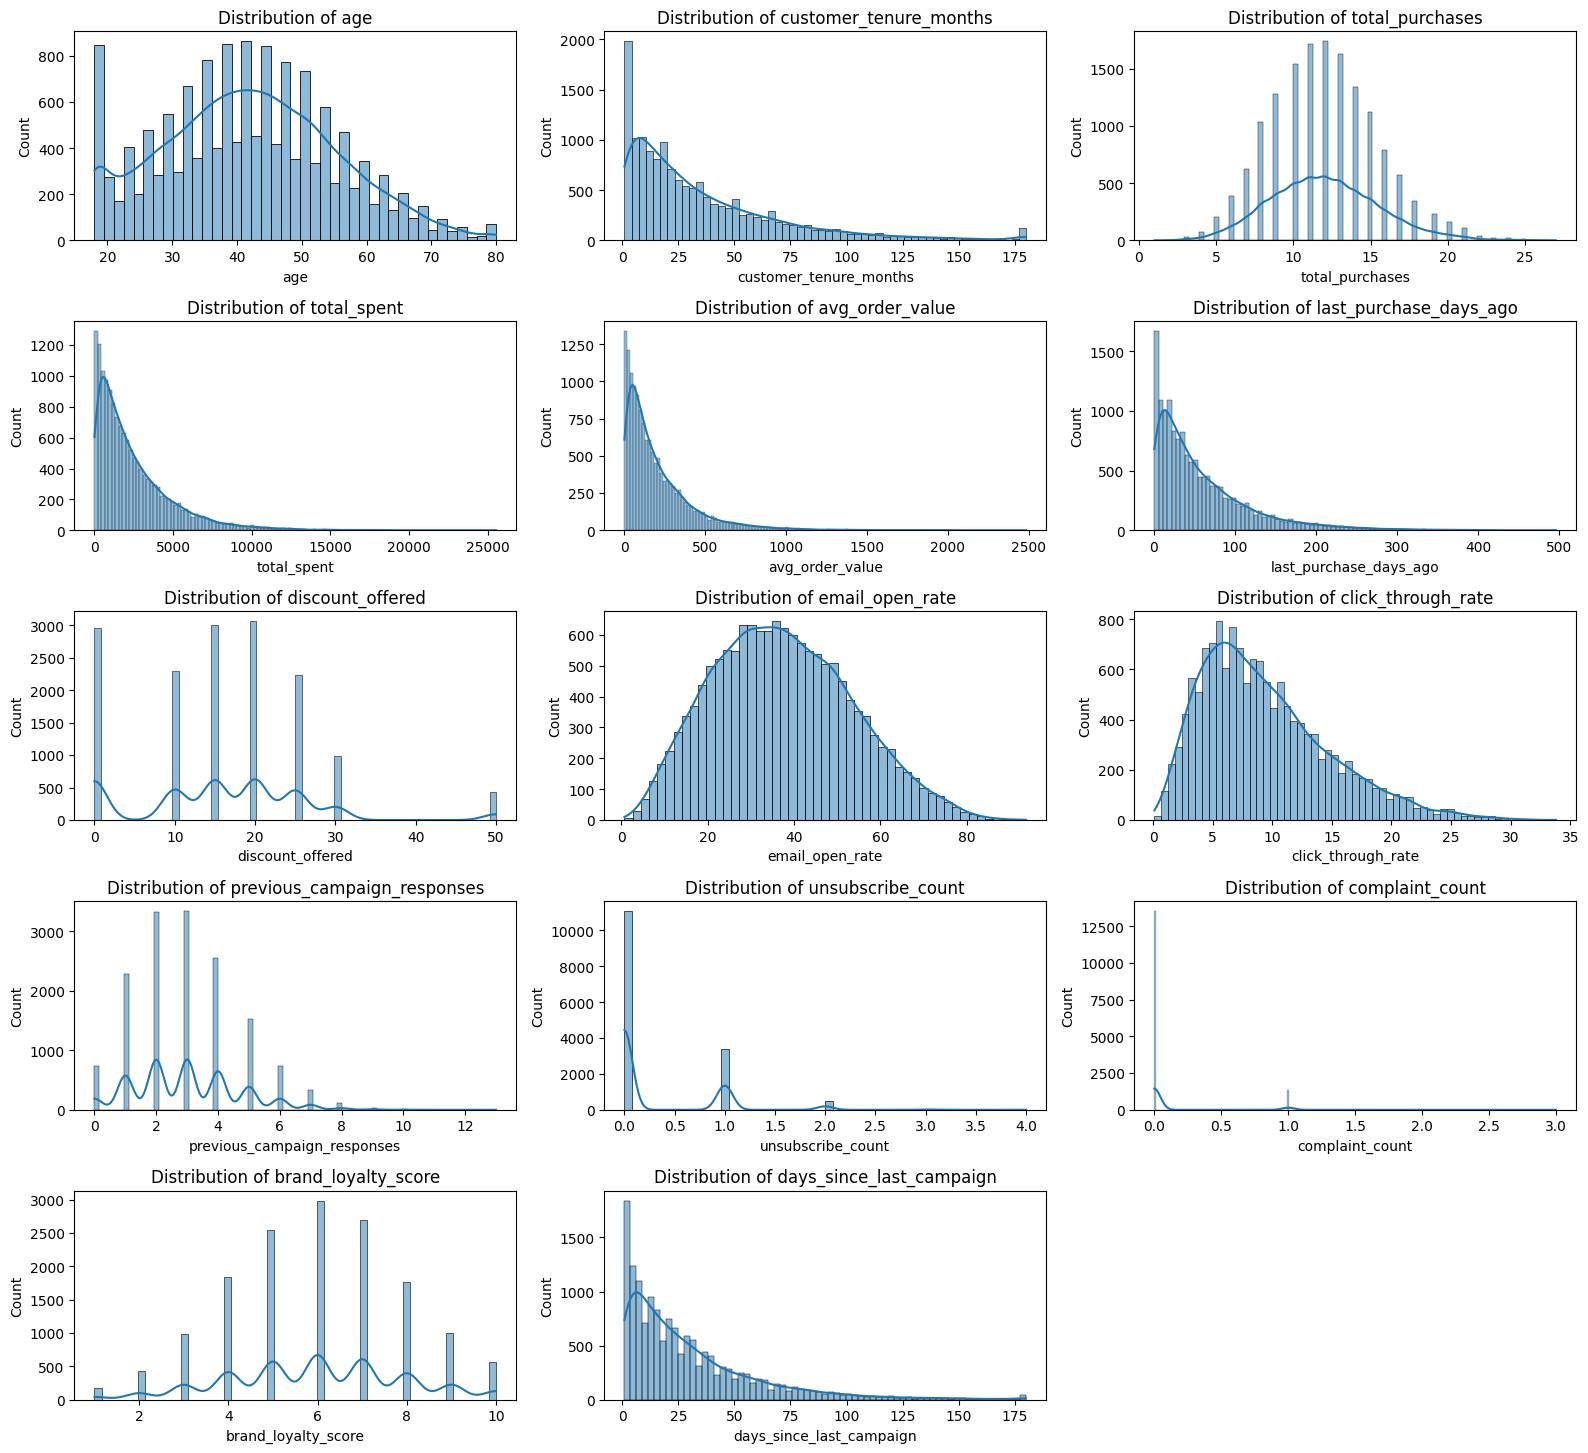

In [8]:
# All graph representations
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(16,20))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(7, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


#### 3B Countplots for Categorical Columns

C:\Users\AvinaashVenkatB\AppData\Local\Temp\ipykernel_576\3978831363.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


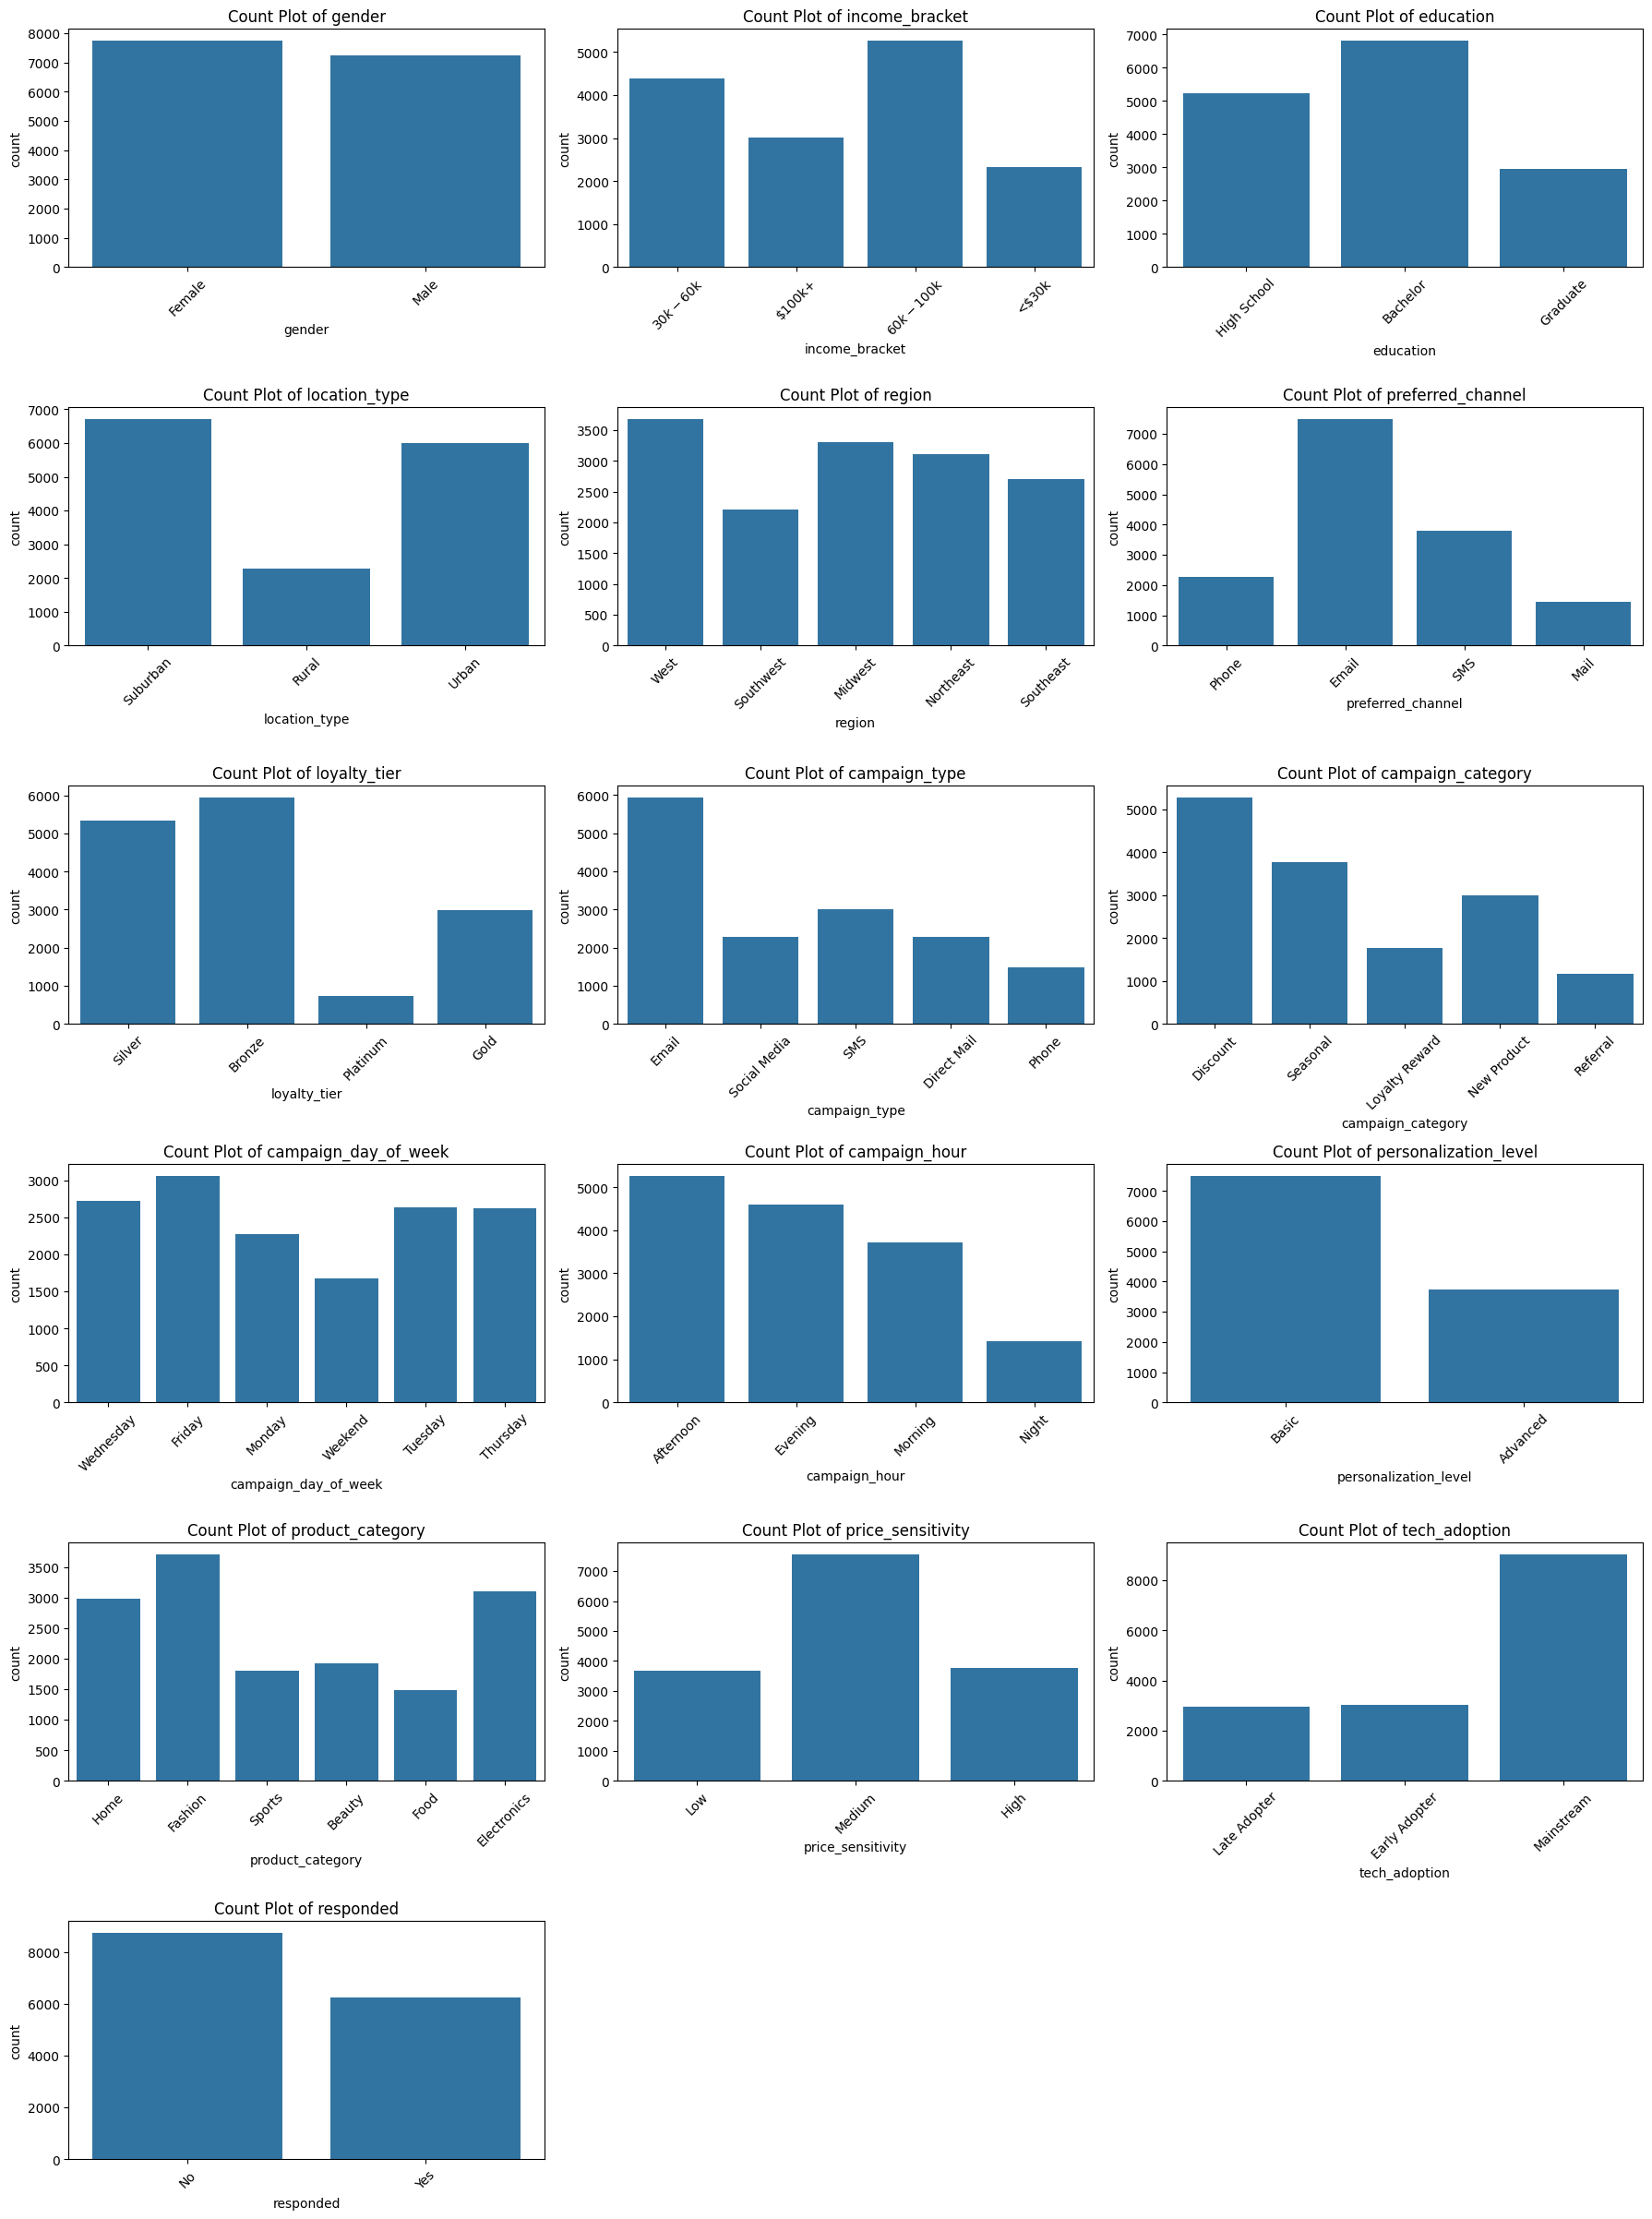

In [9]:
# For categorical columns
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = categorical_cols.drop(['customer_id'])
plt.figure(figsize=(18,40))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(10, 3, i)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

##### 3-C Check target distribution (Univariate)

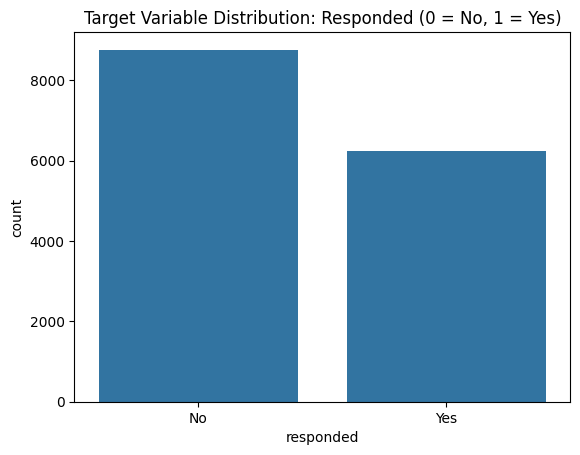

responded
No     0.5838
Yes    0.4162
Name: proportion, dtype: float64

In [10]:
sns.countplot(data=df, x='responded')
plt.title("Target Variable Distribution: Responded (0 = No, 1 = Yes)")
plt.show()
df['responded'].value_counts(normalize=True)

#### 3-D Outlier detection Using Box Plot

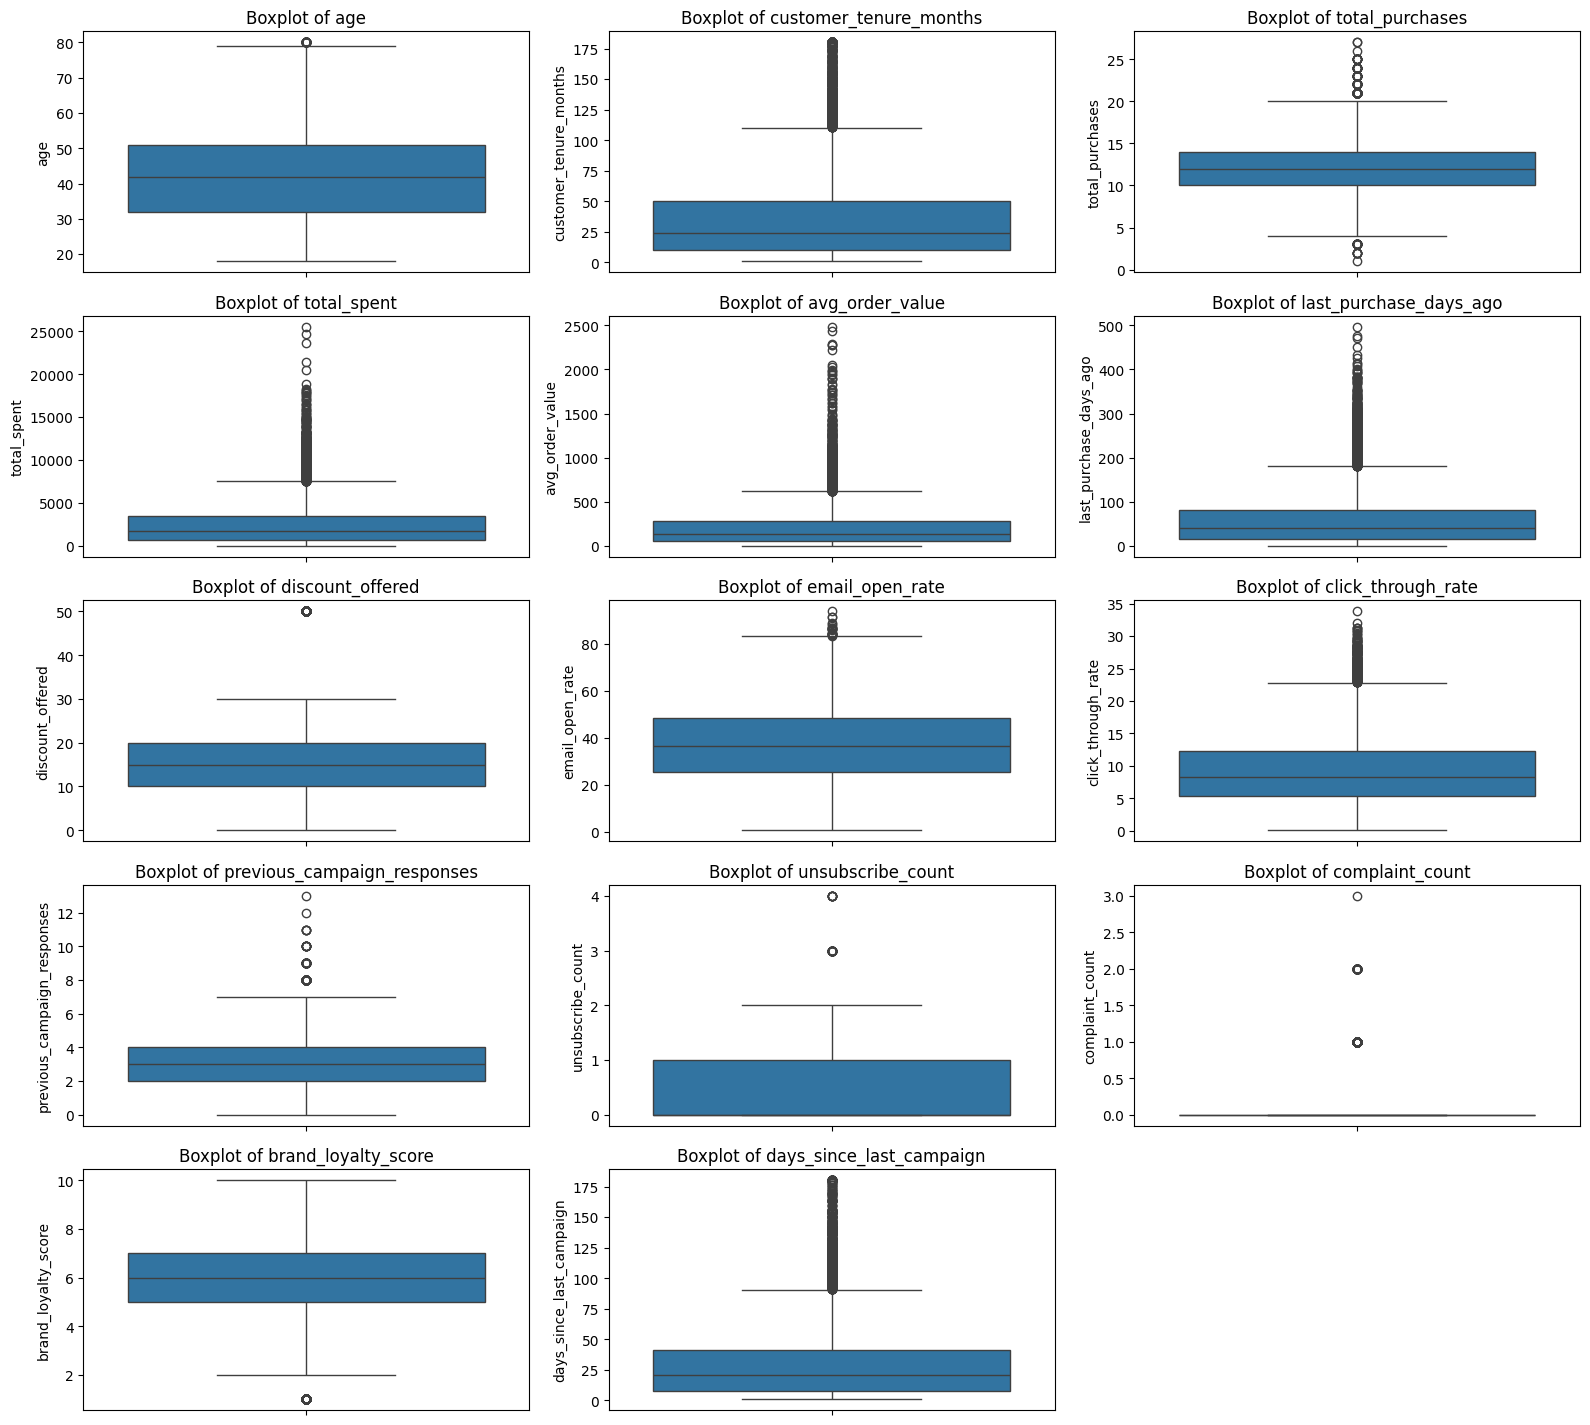

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(16,20))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(7, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

#### 4.Data Cleaning


In [12]:
# Checking Null values
print(df.isnull().sum().sum())

5564


In [13]:
# Handleing Null values 

In [14]:
df['avg_order_value']=df['avg_order_value'].fillna(df['total_spent']/df['total_purchases'].replace(0,1))
df['email_open_rate']=df['email_open_rate'].fillna(df['email_open_rate'].median())
df['click_through_rate']=df['click_through_rate'].fillna(df['click_through_rate'].median())
df['personalization_level']=df['personalization_level'].fillna("Unknown")

In [15]:
print(df.isnull().sum())

customer_id                    0
age                            0
gender                         0
income_bracket                 0
education                      0
location_type                  0
region                         0
customer_tenure_months         0
total_purchases                0
total_spent                    0
avg_order_value                0
last_purchase_days_ago         0
preferred_channel              0
loyalty_tier                   0
campaign_type                  0
campaign_category              0
discount_offered               0
campaign_day_of_week           0
campaign_hour                  0
personalization_level          0
email_open_rate                0
click_through_rate             0
previous_campaign_responses    0
unsubscribe_count              0
complaint_count                0
product_category               0
price_sensitivity              0
brand_loyalty_score            0
tech_adoption                  0
days_since_last_campaign       0
responded 

In [16]:
df['responded']=df['responded'].map({'Yes':1,'No':0})

In [17]:
df.head(10)

,customer_id,age,gender,income_bracket,education,location_type,region,customer_tenure_months,total_purchases,total_spent,...,click_through_rate,previous_campaign_responses,unsubscribe_count,complaint_count,product_category,price_sensitivity,brand_loyalty_score,tech_adoption,days_since_last_campaign,responded
0,CUST_00000001,45,Female,$30k-$60k,High School,Suburban,West,180,13,2645.83,...,8.3,4,1,0,Home,Low,6,Late Adopter,14,0
1,CUST_00000002,25,Female,$100k+,Bachelor,Suburban,Southwest,8,19,1105.91,...,13.8,1,0,0,Fashion,Medium,6,Early Adopter,7,0
2,CUST_00000003,51,Male,$60k-$100k,Bachelor,Suburban,West,1,8,7454.98,...,8.2,8,0,0,Fashion,Medium,5,Mainstream,1,0
3,CUST_00000004,28,Male,$100k+,Graduate,Suburban,Midwest,108,7,2408.26,...,12.1,2,0,0,Sports,Low,6,Early Adopter,3,0
4,CUST_00000005,39,Female,$30k-$60k,Bachelor,Suburban,West,24,13,3952.23,...,10.5,2,0,0,Beauty,Medium,6,Late Adopter,14,0
5,CUST_00000006,36,Female,<$30k,Bachelor,Suburban,Southwest,23,9,9366.64,...,3.2,0,0,0,Beauty,Medium,8,Late Adopter,11,1
6,CUST_00000007,47,Female,$100k+,High School,Rural,Midwest,1,10,622.47,...,11.5,3,1,0,Beauty,Medium,8,Late Adopter,4,1
7,CUST_00000008,46,Male,$100k+,Graduate,Urban,Northeast,1,11,8371.79,...,2.5,5,0,0,Fashion,Low,5,Mainstream,48,1
8,CUST_00000009,36,Female,$30k-$60k,High School,Suburban,Midwest,37,9,370.25,...,5.4,3,0,0,Sports,High,8,Late Adopter,36,0
9,CUST_00000010,51,Male,<$30k,Graduate,Suburban,Midwest,62,11,8033.70,...,6.9,4,0,0,Home,Low,3,Mainstream,11,1


#### 5.Feature Engineering


#####       CORRELATION HEAT MAP 

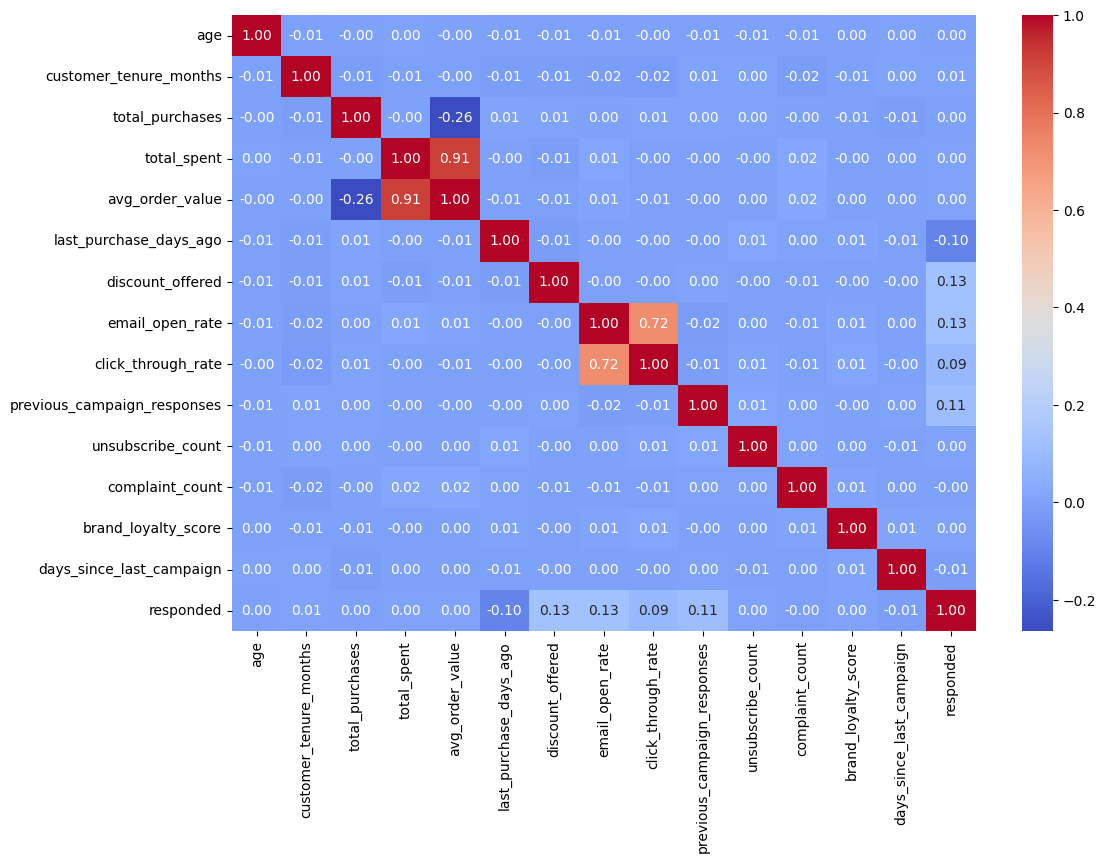

In [18]:
# Heat map for removing repeated columns and for creating hypothesis
import matplotlib.pyplot as plt
import seaborn as sns
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap = 'coolwarm', annot = True, fmt = ".2f")
plt.show()
print(corr['])

In [19]:
# Creating new columns For better understanding
# 1.Customer Value Score
df['customer_value'] = df['total_spent'] / df['customer_tenure_months']

In [20]:
# 2. Purchase Frequency
df['purchase_frequency'] = df['total_purchases'] / df['customer_tenure_months']


In [21]:
# 3. Recency Category
df['recency_bucket'] = pd.cut(df['last_purchase_days_ago'],
                              bins=[0,30,90,180,999],
                              labels=['Very Recent','Recent','Not Recent','Dormant'])

In [22]:
df['high_engagement'] = ((df['email_open_rate'] >= 40) | (df['click_through_rate'] >= 8)).astype(int)

In [23]:
# Not very much useful but ti hypothesis I use this
import numpy as np
def manual_response_rule(row):
    if row['loyalty_tier'] in ['Platinum', 'Gold']:
        loyalty_score = 3
    elif row['loyalty_tier'] == 'Silver':
        loyalty_score = 2
    else:
        loyalty_score = 1
    if row['email_open_rate'] >= 40:
        open_score = 3
    elif row['email_open_rate'] >= 20:
        open_score = 2
    else:
        open_score = 1
    if row['click_through_rate'] >= 8:
        click_score = 3
    elif row['click_through_rate'] >= 4:
        click_score = 2
    else:
        click_score = 1
    if loyalty_score == 3 and open_score == 3:
        return 1
    if loyalty_score >= 2 and (open_score >= 2 or click_score >= 2):
        return 1
    if click_score == 3:
        return 1
    return 0
df['manual_response'] = df.apply(manual_response_rule, axis=1)


##### Engagement score

In [24]:
# Very important 
df["engagement_score"] = df["email_open_rate"]*0.6 + df["click_through_rate"]*0.4

In [ ]:
display(df)

##### 6 HYPOETHSIS

##### 1 Higher Discounts Increase Response Rate

In [29]:
# H1: Discount Offered vs Response
# H0 (Null Hypothesis):
# There is no difference in mean discount_offered between customers who responded and those who did not respond.
# H1 (Alternative Hypothesis):
# There is a significant difference in mean discount_offered between responders and non‑responders.

In [38]:
from scipy.stats import ttest_ind

# Split the dataset into two groups
responders = df[df['responded'] == 1]
nonresponders = df[df['responded'] == 0]

# T-test for discount offered
stat, p = ttest_ind(responders['discount_offered'],nonresponders['discount_offered'],equal_var=False)

print("H1 — T-test: Discount Offered vs Responded")
print("T-statistic:", stat)
print("P-value:", f"{p:.100f}")
if p < 0.05:
    print("Reject H0: Discount offered significantly influences response.")
else:
    print("Fail to reject H0: No significant relationship found.")

H1 — T-test: Discount Offered vs Responded
T-statistic: 15.616858532652488
P-value: 0.0000000000000000000000000000000000000000000000000000017155314215779605792388819017152471899969886667
Reject H0: Discount offered significantly influences response.


##### 2 email_open_rate

In [ ]:
# H0:Responders and nonresponders have same mean email open rate.
# H1:Responders have a different/higher email open rate.

In [37]:
stat, p = ttest_ind(
    responders['email_open_rate'],nonresponders['email_open_rate'],equal_var=False)

print("\nH2A — Email Open Rate T-test")
print("T-statistic:", stat)
print("P-value:", f"{p:.100f}")

if p < 0.05:
    print("Reject H0: Email open rate significantly affects response.")
else:
    print("Fail to reject H0.")


H2A — Email Open Rate T-test
T-statistic: 15.609335843730493
P-value: 0.0000000000000000000000000000000000000000000000000000019442966994355314485209206365136729369568681102
Reject H0: Email open rate significantly affects response.


##### 3 Click Through Rate

In [ ]:
# H0:Responders and nonresponders have same mean CTR.
# H1:Responders have significantly higher CTR.

In [40]:
stat, p = ttest_ind(
    responders['click_through_rate'],
    nonresponders['click_through_rate'],
    equal_var=False
)

print("\nH2B — Click Through Rate T-test")
print("T-statistic:", stat)
print("P-value:", f"{p:.100f}")
if p < 0.05:
    print("Reject H0: Click-through rate significantly affects response.")
else:
    print("Fail to reject H0.")


H2B — Click Through Rate T-test
T-statistic: 10.724159894964007
P-value: 0.0000000000000000000000000101590618928628678493254584241069055397547647514257215215245830610955890018
Reject H0: Click-through rate significantly affects response.
